# Who will accept the coupon?

## Overview

The goal of this project is to explore a dataset of driving scenarios where users were offered coupons and determine what types of customers are more likely to accept them. By analyzing customer demographics, behavior, and contextual factors, we aim to identify patterns that influence coupon acceptance.

## Context

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

## Data

This data comes from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \\$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\\$20 - $50).

## Data Description

The attributes of this data set include:

1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    
2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical location of the user, destination, and the venue, and we mark the distance between each two places with time of driving. The user can see whether the venue is in the same direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)

3. Coupon attributes
    - time before it expires: 2 hours or one day

## Tools and Libraries

The project uses Python and several common data analysis libraries:

-   Python
-   Pandas
-   NumPy
-   Plotly
-   Seaborn / Matplotlib
-   Jupyter Notebook

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px

In [27]:
original_data = pd.read_csv('data/coupons.csv')
data = original_data.copy()
print(f"Number of entries: {original_data.shape[0]}.")
original_data.head()

Number of entries: 12684.


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


## Missing and Problematic Data

First look for missing data.

In [14]:
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

In [15]:
print(original_data['car'].value_counts())

car
Scooter and motorcycle                      22
Mazda5                                      22
do not drive                                22
crossover                                   21
Car that is too old to install Onstar :D    21
Name: count, dtype: int64


There are 12684 entries, of which 12576 are missing data for the 'car' column. The data present for the car column is not very useful. This column will not be used and dropped.

In [31]:
data = data.drop(columns=['car'])
data.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway',
       'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ5min',
       'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same',
       'direction_opp', 'Y'],
      dtype='object')

In [32]:
print(data['Bar'].value_counts())
print(data['CoffeeHouse'].value_counts())
print(data['CarryAway'].value_counts())
print(data['RestaurantLessThan20'].value_counts())
print(data['Restaurant20To50'].value_counts())

Bar
never    5304
less1    3482
1~3      2473
4~8      1076
gt8       349
Name: count, dtype: int64
CoffeeHouse
less1    3385
1~3      3225
never    3179
4~8      1784
gt8      1111
Name: count, dtype: int64
CarryAway
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     304
Name: count, dtype: int64
RestaurantLessThan20
1~3      5376
4~8      3580
less1    2093
gt8      1285
never     350
Name: count, dtype: int64
Restaurant20To50
less1    6077
1~3      3290
never    2325
4~8       728
gt8       264
Name: count, dtype: int64


The other 5 columns that contain missing data are structured similarly, with values ranging from 'never' to 'gt8'. The entries that contain missing data can either be dropped, or filled in with an assumption. For this study, empty cells will be treated as 'never', and filled in as such.

In [33]:
cols_with_missing = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']
data[cols_with_missing] = data[cols_with_missing].fillna('never')
data.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

In [56]:
data.sample(10)

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
7677,Home,Alone,Snowy,30,6PM,Coffee House,1d,Male,36,Single,...,never,1~3,less1,less1,1,1,0,0,1,0
5391,No Urgent Place,Alone,Sunny,80,10AM,Bar,1d,Female,26,Unmarried partner,...,1~3,1~3,1~3,1~3,1,0,0,0,1,1
12270,Home,Alone,Sunny,80,6PM,Carry out & Take away,2h,Male,26,Single,...,gt8,4~8,4~8,4~8,1,1,0,1,0,1
5020,Home,Alone,Sunny,80,10PM,Restaurant(<20),2h,Female,31,Married partner,...,never,1~3,gt8,1~3,1,0,0,1,0,1
9522,Home,Partner,Sunny,55,10PM,Bar,1d,Male,31,Unmarried partner,...,less1,1~3,1~3,never,1,1,1,0,1,0
2251,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,never,1~3,less1,never,1,0,0,0,1,0
5095,Home,Alone,Sunny,80,10PM,Restaurant(<20),2h,Male,21,Single,...,1~3,4~8,1~3,less1,1,0,0,1,0,0
12522,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,...,never,never,1~3,never,1,1,1,0,1,0
266,No Urgent Place,Kid(s),Sunny,80,10AM,Restaurant(<20),2h,Female,31,Married partner,...,less1,1~3,less1,less1,1,1,0,0,1,1
11612,Work,Alone,Sunny,80,7AM,Restaurant(20-50),2h,Female,21,Single,...,never,less1,never,never,1,0,0,1,0,0


The Bar, CoffeeHouse, CarryAway, RestaurantLessThan20, and Restaurant20To50 columns are really category columns. Changing them to a panda's Categorical type will allow the order to be specified, which will be real useful for graphs and analysis. The same issue exists with the age and time columns, where the column is really categories and not just a number.

In [64]:
data['coupon'].value_counts()

coupon
Coffee House             3996
Restaurant(<20)          2786
Carry out & Take away    2393
Bar                      2017
Restaurant(20-50)        1492
Name: count, dtype: int64

In [199]:
coupon_order = ['Bar','Coffee House','Carry out & Take away','Restaurant(<20)','Restaurant(20-50)']
data['coupon'] = pd.Categorical(data['coupon'], categories=coupon_order, ordered=True)
freq_order = ['never','less1','1~3','4~8','gt8']
data['Bar'] = pd.Categorical(data['Bar'], categories=freq_order, ordered=True)
data['CoffeeHouse'] = pd.Categorical(data['CoffeeHouse'], categories=freq_order, ordered=True)
data['CarryAway'] = pd.Categorical(data['CarryAway'], categories=freq_order, ordered=True)
data['RestaurantLessThan20'] = pd.Categorical(data['RestaurantLessThan20'], categories=freq_order, ordered=True)
data['Restaurant20To50'] = pd.Categorical(data['Restaurant20To50'], categories=freq_order, ordered=True)
age_order = ['below21', '21', '26', '31', '36', '41', '46', '50plus']
data['age'] = pd.Categorical(data['age'], categories=age_order, ordered=True)
time_order = ['7AM','10AM','2PM','6PM','10PM']
data['time'] = pd.Categorical(data['time'], categories=time_order, ordered=True)
income_order = ['Less than $12500','$12500 - $24999','$25000 - $37499','$37500 - $49999','$50000 - $62499','$62500 - $74999','$75000 - $87499','$87500 - $99999','$100000 or More']
data['income'] = pd.Categorical(data['income'], categories=income_order, ordered=True)

## General Coupon Acceptance Analysis

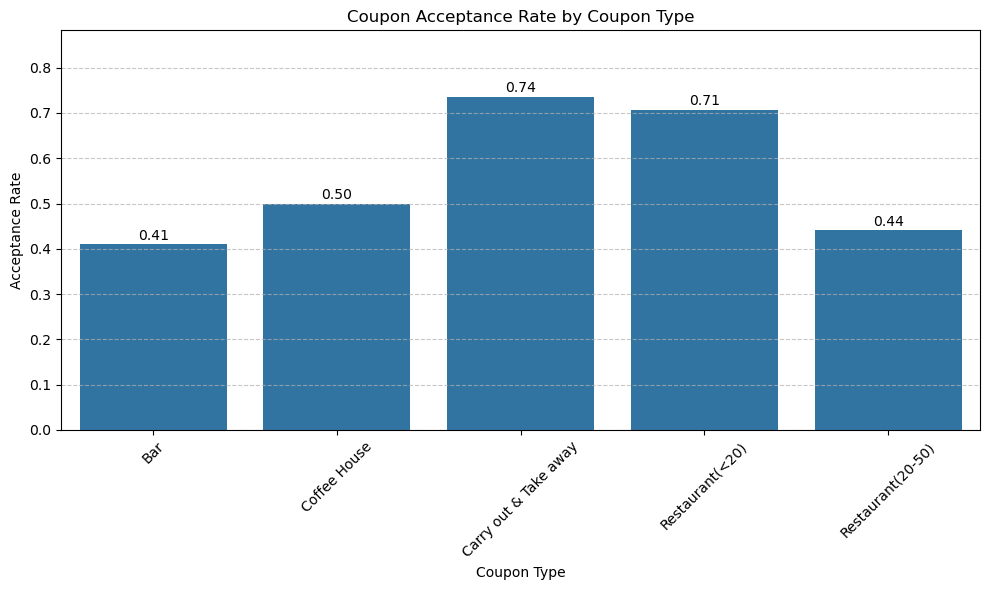

In [258]:
coupon_acceptance = data.groupby('coupon', observed=True)['Y'].mean().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=coupon_acceptance,
    x='coupon',
    y='Y'
)

for i, row in coupon_acceptance.iterrows():
    ax.text(
        i, 
        row['Y'] + 0.01, 
        f"{row['Y']:.2f}", 
        ha='center'
    )

plt.title('Coupon Acceptance Rate by Coupon Type')
plt.xlabel('Coupon Type')
plt.ylabel('Acceptance Rate')

plt.ylim(0, coupon_acceptance['Y'].max() * 1.2)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(False)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

This chart compares acceptance rates across coupon categories. Coffee house and close-by restaurant coupons have higher acceptance rates, while bar coupons have lower acceptance overall, suggesting behavioral targeting may be more important for bar and coffee house coupons.

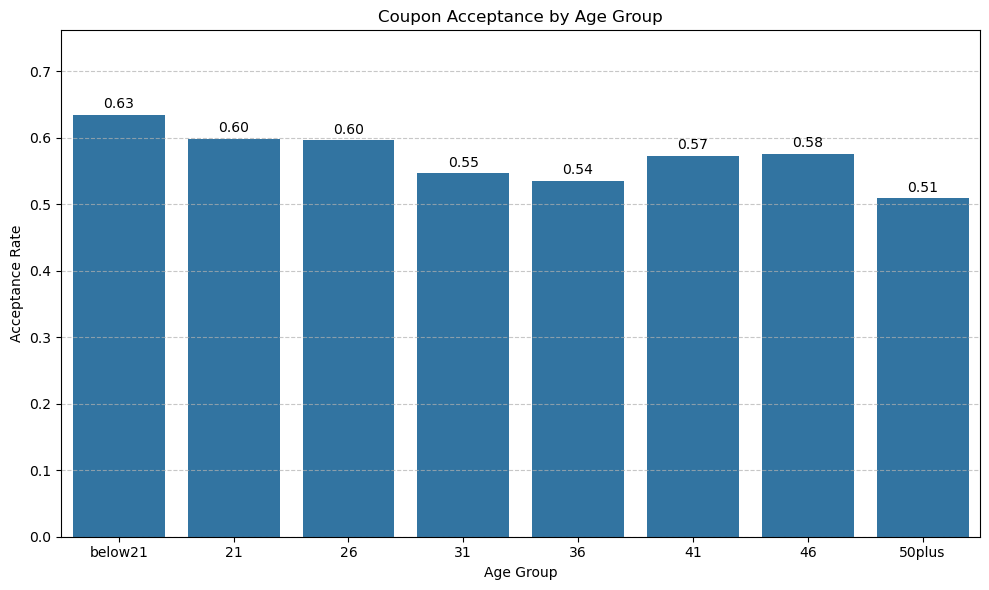

In [257]:
age_acceptance = data.groupby('age', observed=True)['Y'].mean().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=age_acceptance,
    x='age',
    y='Y'
)

for i, row in age_acceptance.iterrows():
    ax.text(
        i,
        row['Y'] + 0.01,
        f"{row['Y']:.2f}",
        ha='center'
    )

plt.title('Coupon Acceptance by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Acceptance Rate')

plt.ylim(0, age_acceptance['Y'].max() * 1.2)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

This chart examines overall coupon acceptance by age group. It shows a slight tendency for younger age groups to accept coupons more frequently. However, this relationship appears weak on its own. To better understand how age influences coupon acceptance, behavioral and contextual factors, such as driving situation or past visiting habits, need to be considered alongside age.

## Bar Coupon Acceptance Analysis

In [57]:
bar_data = data[data['coupon'] == 'Bar'].copy()

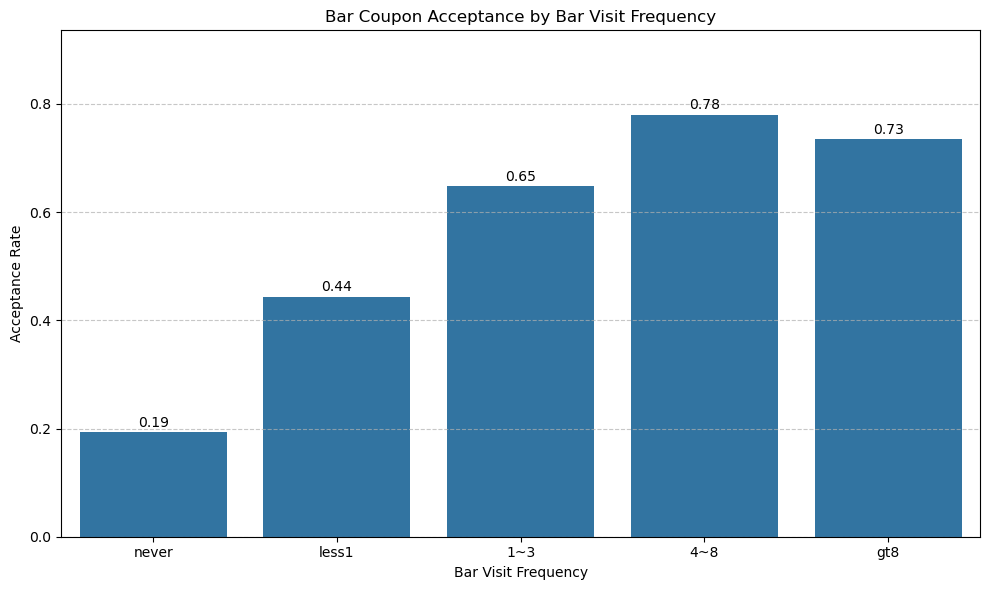

Acceptance rate of bar coupons for persons visiting bars less than once a month: 29.35%
Acceptance rate of bar coupons for persons visiting bars more than once a month: 68.79%


In [256]:
bar_freq_acceptance = bar_data.groupby('Bar', observed=True)['Y'].mean().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=bar_freq_acceptance,
    x='Bar',
    y='Y'
)

for i, row in bar_freq_acceptance.iterrows():
    ax.text(
        i,
        row['Y'] + 0.01,
        f"{row['Y']:.2f}",  # or .0% for percentage
        ha='center'
    )

plt.title('Bar Coupon Acceptance by Bar Visit Frequency')
plt.xlabel('Bar Visit Frequency')
plt.ylabel('Acceptance Rate')

plt.ylim(0, bar_freq_acceptance['Y'].max() * 1.2)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

bar_less_than_once = bar_data[bar_data['Bar'].isin(['never', 'less1'])]
bar_over_once = bar_data[bar_data['Bar'].isin(['1~3', '4~8', 'gt8'])]
print(f"Acceptance rate of bar coupons for persons visiting bars less than once a month: {bar_less_than_once['Y'].mean():.2%}")
print(f"Acceptance rate of bar coupons for persons visiting bars more than once a month: {bar_over_once['Y'].mean():.2%}")

When analyzing bar coupon acceptance, bar visitation frequency appears to be a strong predictor of whether a coupon will be accepted. Drivers who visit bars more than once per month accept bar coupons at more than twice the rate of those who visit less frequently. This suggests that targeting bar coupons toward customers who already visit bars regularly would likely be a more effective promotional strategy.

In [208]:
heatmap_data = bar_data.pivot_table(
    values='Y',
    index='Bar',
    columns='age',
    aggfunc='mean',
    observed=True
)
fig = px.imshow(
    heatmap_data,
    text_auto=True,
    aspect="auto",
    title="Bar Coupon Acceptance Rate: Bar Visits vs Age Group",
    labels=dict(
        x="Age",
        y="Bar Visit Frequency",
        color="Acceptance Rate"
    )
)
fig.show()

This heatmap illustrates bar coupon acceptance rates across age groups and bar visitation frequency. The results show that coupon acceptance generally increases as bar visitation frequency increases, regardless of age group. While some age-related variation exists, behavioral factors such as bar visitation appear to be a stronger predictor of coupon acceptance than demographics alone. Frequent bar-goers, particularly in younger to middle-aged segments, represent the most responsive target group for bar-related promotions. There is a 100% acceptance for the segment of greater than 8 frequency and age of 50plus, that should be investigated.

In [91]:
bar_data.groupby(['Bar','age'],observed=True)['Y'].agg(['mean','count'])

mean  count
Bar   age                     
never below21  0.400000     65
      21       0.230769    143
      26       0.174825    143
      31       0.186047    129
      36       0.211111     90
      41       0.172414     58
      46       0.163934     61
      50plus   0.104938    162
less1 below21  0.500000     12
      21       0.592593    108
      26       0.445783     83
      31       0.333333    114
      36       0.303797     79
      41       0.522727     88
      46       0.500000     32
      50plus   0.407407     54
1~3   below21  0.333333      6
      21       0.635514    107
      26       0.718750     96
      31       0.647887     71
      36       0.500000     28
      41       0.642857     28
      46       0.666667      9
      50plus   0.653846     52
4~8   21       0.750000     44
      26       0.854545     55
      31       0.875000     16
      36       0.500000     12
      41       0.750000      4
      46       0.857143      7
      50plus   0.666667     12
gt8   below21  0.500000      4
      21       0.866667     15
      26       0.833333     18
      31       0.333333      9
      50plus   1.000000      3

From the above counts, there were only 3 entries for the segment corresponding to greater than 8 visits and 50 or over age. This segment contains very few observations, suggesting that the result may be driven by a small sample size rather than a reliable trend.

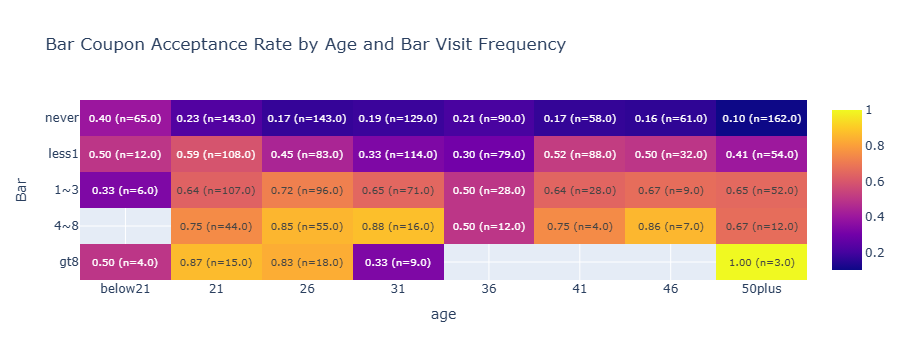

In [94]:
bar_heatmap_rate_data = bar_data.pivot_table(
    values='Y',
    index='Bar',
    columns='age',
    aggfunc='mean',
    observed=True
)

bar_heatmap_count_data = bar_data.pivot_table(
    values='Y',
    index='Bar',
    columns='age',
    aggfunc='count',
    observed=True
)

bar_heatmap_annotation = bar_heatmap_rate_data.copy().astype(object)

for r in bar_heatmap_rate_data.index:
    for c in bar_heatmap_rate_data.columns:
        rate = bar_heatmap_rate_data.loc[r, c]
        count = bar_heatmap_count_data.loc[r, c]
        if pd.notna(rate):
            bar_heatmap_annotation.loc[r, c] = f"{rate:.2f}\n(n={count})"
        else:
            bar_heatmap_annotation.loc[r, c] = ""

fig = px.imshow(
    bar_heatmap_rate_data,
    text_auto=False,
    aspect="auto",
    title="Bar Coupon Acceptance Rate by Age and Bar Visit Frequency"
)

fig.update_traces(text=bar_heatmap_annotation.values, texttemplate="%{text}")

fig.show()

This heatmap combines both acceptance rate and sample size in a single visualization. It allows us to see not only where coupon acceptance is highest, but also whether those results are supported by a meaningful number of observations. This helps distinguish statistically meaningful patterns from potential outliers caused by small sample sizes.

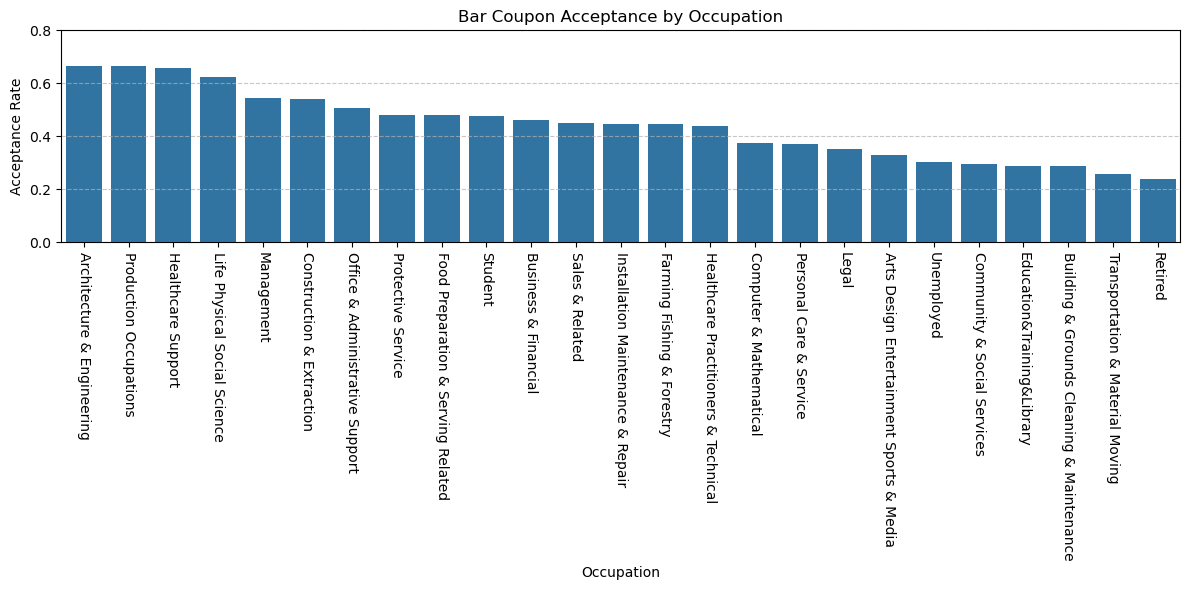

In [252]:
bar_occupation_acceptance = (
    bar_data.groupby('occupation', observed=True)['Y']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=bar_occupation_acceptance,
    x='occupation',
    y='Y'
)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.title('Bar Coupon Acceptance by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Acceptance Rate')

plt.xticks(rotation=-90, ha='center')

plt.ylim(0, bar_occupation_acceptance['Y'].max() * 1.2)

plt.tight_layout()
plt.show()

In [97]:
#bar_data['occupation'].value_counts()
bar_top_3_occupation_list = ['Architecture & Engineering','Production Occupations','Healthcare Support']
bar_bottom_3_occupation_list = ['Building & Grounds Cleaning & Maintenance','Transportation & Material Moving','Retired']
bar_top_3_occupation = bar_data[bar_data['occupation'].isin(bar_top_3_occupation_list)]
bar_bottom_3_occupation = bar_data[bar_data['occupation'].isin(bar_bottom_3_occupation_list)]
print(f"Acceptance rate of bar coupons for persons in top 3 occupations: {bar_top_3_occupation['Y'].mean():.2%}")
print(f"Acceptance rate of bar coupons for persons in bottom 3 occupations: {bar_bottom_3_occupation['Y'].mean():.2%}")

Acceptance rate of bar coupons for persons in top 3 occupations: 66.29%
Acceptance rate of bar coupons for persons in bottom 3 occupations: 24.79%


This graph shows that occupation may also influence bar coupon acceptance. The top three occupations exhibit acceptance rates more than twice as high as those of the bottom three occupations, suggesting that occupational differences may play a role in the effectiveness of bar coupon promotions.

### Bar Coupon Acceptance Summary

Analysis of bar coupon acceptance suggests that behavioral factors play the strongest role in determining whether a coupon will be accepted. Drivers who visit bars more than once per month accept bar coupons at more than twice the rate of those who visit bars less frequently, indicating that past visitation behavior is a strong predictor of responsiveness. Age and occupation also show some variation in acceptance rates, though their influence appears secondary compared to bar visitation frequency. Additionally, certain segments with extremely high acceptance rates were found to have very small sample sizes, suggesting those results should be interpreted cautiously. Overall, the most effective targeting strategy for bar coupons would focus on customers who already visit bars regularly, particularly within younger to middle-aged segments where acceptance rates tend to be higher.

#### Next Steps

Validate high-performing segments with low sample sizes. Re-examine segments with extremely high acceptance but small counts to ensure those patterns are reliable. Compare demographic groups more closely. While age and occupation are important, a deeper look might still reveal other specific groups that are worth targeting.

#### Recommendations

Prioritize frequent bar-goers. Focus campaigns on users who already visit bars regularly, as they show significantly higher acceptance rates. Time promotions for evening and social contexts. Align coupon delivery with typical bar-going times and situations, such as evenings or when users are with friends.

## Coffee House Coupon Acceptance Analysis

In [114]:
coffee_data = data[data['coupon'] == 'Coffee House'].copy()

In [263]:
coffee_freq = (
    coffee_data.groupby('CoffeeHouse', observed=True)['Y']
    .mean()
)
print(coffee_freq)

CoffeeHouse
never    0.208208
less1    0.481860
1~3      0.647793
4~8      0.685874
gt8      0.657895
Name: Y, dtype: float64


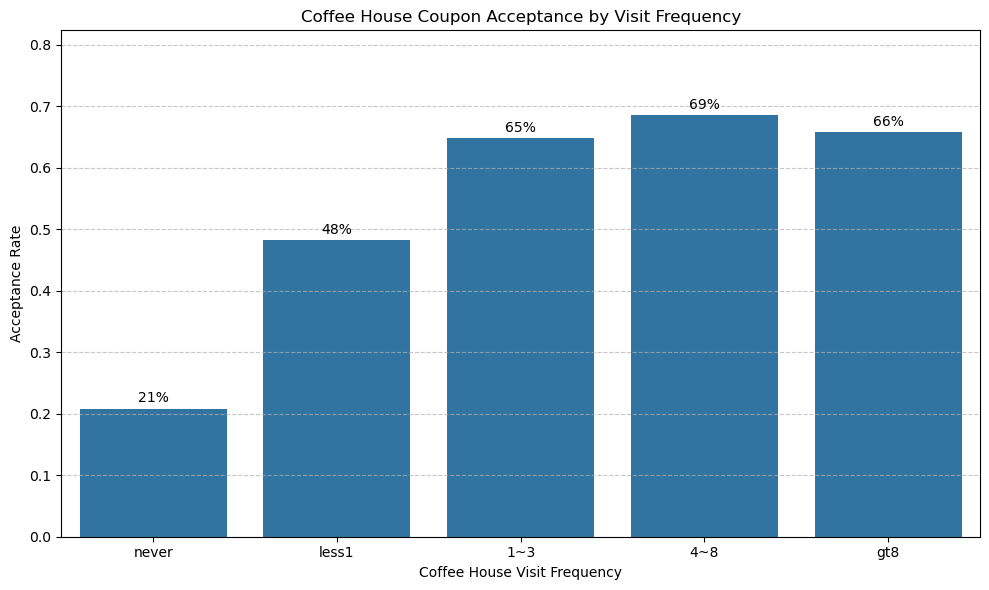

In [264]:
coffee_freq = coffee_freq.reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=coffee_freq,
    x='CoffeeHouse',
    y='Y'
)

for i, row in coffee_freq.iterrows():
    ax.text(
        i,
        row['Y'] + 0.01,
        f"{row['Y']:.0%}",
        ha='center'
    )

plt.title('Coffee House Coupon Acceptance by Visit Frequency')
plt.xlabel('Coffee House Visit Frequency')
plt.ylabel('Acceptance Rate')

plt.ylim(0, coffee_freq['Y'].max() * 1.2)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

Drivers who frequently visit coffee houses are significantly more likely to accept coffee coupons. Those visiting more than once per month exhibit acceptance rates approximately three times higher than individuals who never visit. This highlights the strong influence of prior behavior on coupon acceptance.

In [207]:
coffee_count_data = coffee_data.pivot_table(
    values='Y',
    index='CoffeeHouse',
    columns='time',
    aggfunc='count',
    observed=True
)

coffee_heatmap_data = (
    coffee_data.pivot_table(
        values='Y',
        index='CoffeeHouse',
        columns='time',
        aggfunc='mean',
        observed=True
    )
)

coffee_annotation = coffee_heatmap_data.copy().astype(object)

for r in coffee_heatmap_data.index:
    for c in coffee_heatmap_data.columns:
        rate = coffee_heatmap_data.loc[r, c]
        count = coffee_count_data.loc[r, c]

        if pd.notna(rate):
            coffee_annotation.loc[r, c] = f"{rate:.0%}\n(n={int(count)})"
        else:
            coffee_annotation.loc[r, c] = ""

fig = px.imshow(
    coffee_heatmap_data,
    text_auto=False,
    aspect='auto',
    title='Coffee Coupon Acceptance: Frequency vs Time of Day',
    labels=dict(
        x="Time",
        y="Coffee House Visit Frequency",
        color="Acceptance Rate"
    )
)
fig.update_traces(text=coffee_annotation.values, texttemplate="%{text}")
fig.show()

This heatmap shows that both coffee house visitation frequency and time of day strongly influence coupon acceptance. Acceptance rates increase consistently with visit frequency, indicating that past behavior is a key predictor of responsiveness. Additionally, acceptance is highest during morning hours, and secondly with mid afternoon. The combination of frequent coffee house visitors and morning time periods represents the most responsive segment for coffee coupon promotions.

passanger
Alone        0.437943
Friend(s)    0.596906
Kid(s)       0.483092
Partner      0.570492
Name: Y, dtype: float64


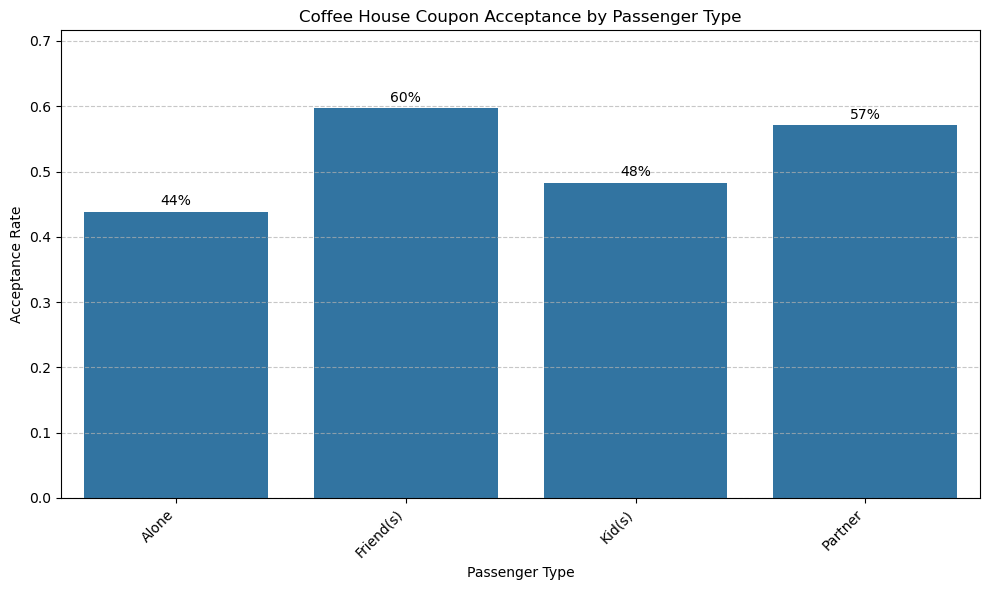

In [255]:
coffee_passenger_acceptance = coffee_data.groupby('passanger')['Y'].mean()
print(coffee_passenger_acceptance)
coffee_passenger_acceptance = coffee_passenger_acceptance.reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=coffee_passenger_acceptance,
    x='passanger',
    y='Y'
)

for i, row in coffee_passenger_acceptance.iterrows():
    ax.text(
        i,
        row['Y'] + 0.01,
        f"{row['Y']:.0%}",
        ha='center'
    )

plt.title('Coffee House Coupon Acceptance by Passenger Type')
plt.xlabel('Passenger Type')
plt.ylabel('Acceptance Rate')

plt.ylim(0, coffee_passenger_acceptance['Y'].max() * 1.2)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(False)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Drivers traveling with friends or partners may show higher acceptance rates compared to those driving alone, suggesting that social context can influence coupon acceptance.

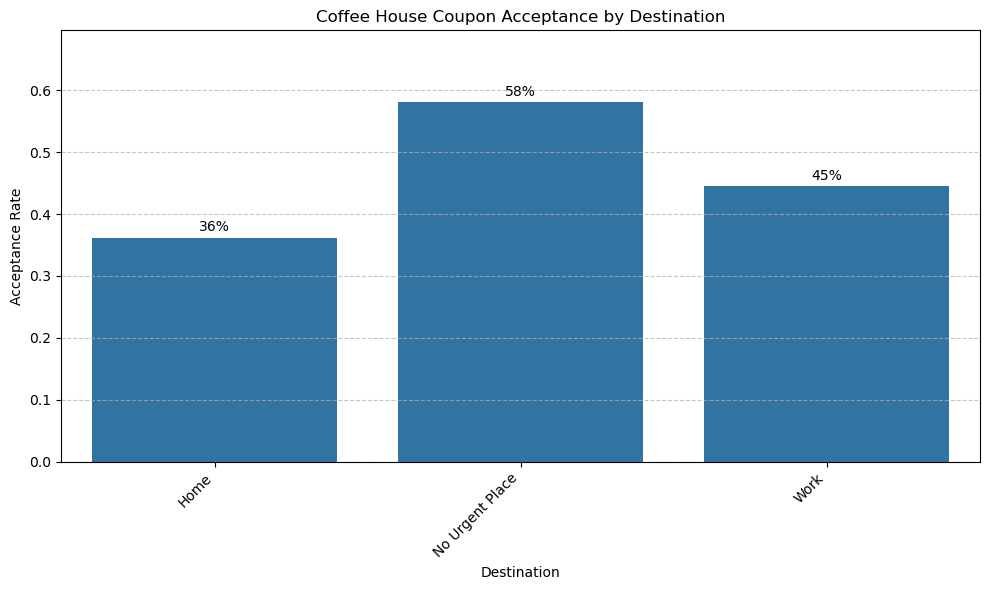

In [265]:
coffee_destination_acceptance = (
    coffee_data.groupby('destination')['Y']
    .mean()
)
coffee_destination_acceptance = coffee_destination_acceptance.reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=coffee_destination_acceptance,
    x='destination',
    y='Y'
)

for i, row in coffee_destination_acceptance.iterrows():
    ax.text(
        i,
        row['Y'] + 0.01,
        f"{row['Y']:.0%}",
        ha='center'
    )

plt.title('Coffee House Coupon Acceptance by Destination')
plt.xlabel('Destination')
plt.ylabel('Acceptance Rate')

plt.ylim(0, coffee_destination_acceptance['Y'].max() * 1.2)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(False)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Destination appears to influence coffee house coupon acceptance, as drivers with no urgent destination are more likely to accept coupons than those traveling to a specific location. This suggests that time flexibility plays a role in coupon responsiveness.

### Coffee House Coupon Acceptance Analysis

Analysis of coffee house coupons shows that acceptance is strongly influenced by both behavioral and contextual factors. Drivers who frequently visit coffee houses are significantly more likely to accept coupons, indicating that past behavior is a key predictor of responsiveness. Time of day also plays an important role, with higher acceptance rates observed during morning and midday periods when coffee consumption is more common. Demographic factors such as age show some variation but are less influential than behavioral patterns. Overall, the most effective targeting strategy for coffee coupons would focus on frequent coffee house visitors during peak consumption times, particularly in the morning.

#### Next Steps

Validate time-of-day patterns across other variables. Break down morning and midday acceptance further by frequency and passenger type to confirm where engagement is strongest. Compare weekday versus weekend behavior, since coffee habits may differ day to day.

#### Recommendations

Target frequent coffee visitors during peak hours. Focus campaigns on users who already visit coffee houses regularly, especially in the morning and midday when demand is highest.

## Restaurant Coupon Acceptance

In [127]:
rest_lt20_data = data[data['coupon'] == 'Restaurant(<20)'].copy()
rest_20_50_data = data[data['coupon'] == 'Restaurant(20-50)'].copy()

In [266]:
res_lt20_freq = rest_lt20_data.groupby('RestaurantLessThan20', observed=True)['Y'].mean()
print(res_lt20t_freq)

   level_0  index RestaurantLessThan20         Y
0        0      0                never  0.666667
1        1      1                less1  0.673913
2        2      2                  1~3  0.702679
3        3      3                  4~8  0.717500
4        4      4                  gt8  0.760417


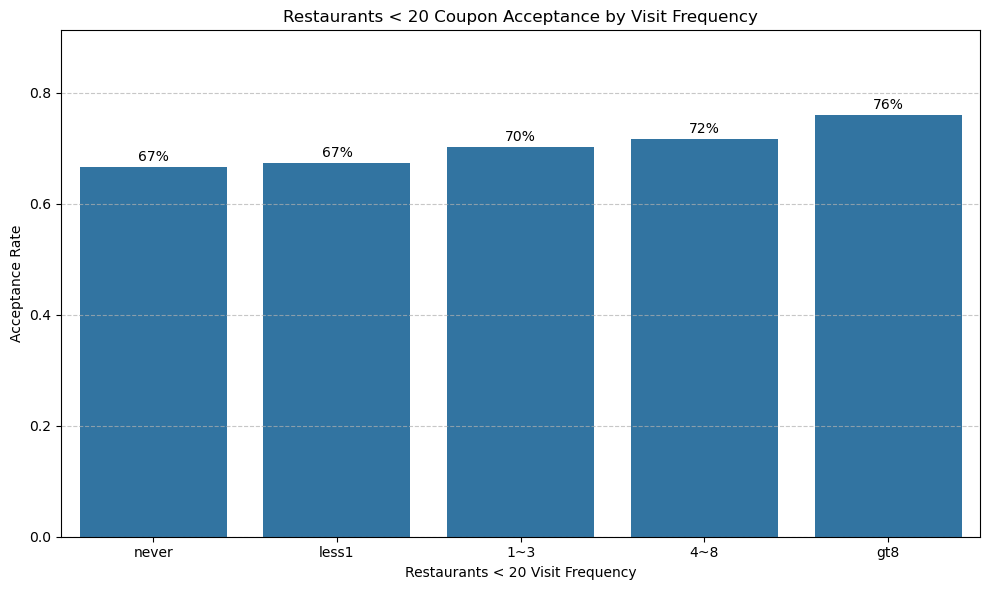

In [268]:
res_lt20_freq = res_lt20_freq.reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=res_lt20_freq,
    x='RestaurantLessThan20',
    y='Y'
)

for i, row in res_lt20_freq.iterrows():
    ax.text(
        i,
        row['Y'] + 0.01,
        f"{row['Y']:.0%}",
        ha='center'
    )

plt.title('Restaurants < 20 Coupon Acceptance by Visit Frequency')
plt.xlabel('Restaurants < 20 Visit Frequency')
plt.ylabel('Acceptance Rate')

plt.ylim(0, res_lt20_freq['Y'].max() * 1.2)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

These acceptance rates for restaurants under $20 are consistently high, with even higher acceptance among more frequent visitors.

In [239]:
rest_lt20_combo = (
    rest_lt20_data
    .groupby(['RestaurantLessThan20', 'passanger', 'time'], observed=True)['Y']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'acceptance_rate', 'count': 'n'})
)

top_segments = rest_lt20_combo.sort_values(by='acceptance_rate', ascending=False)
print(top_segments.head(10))

rest_lt20_combo['label'] = rest_lt20_combo.apply(
    lambda x: f"{int(x['n'])} entries",
    axis=1
)

fig = px.bar(
    rest_lt20_combo,
    x='RestaurantLessThan20',
    y='acceptance_rate',
    color='passanger',
    facet_col='time',
    barmode='group',
    text='label',
    title='Restaurants < 20 Acceptance by Frequency, Passenger, and Time',
    labels={
        'RestaurantLessThan20': 'Frequency',
        'acceptance_rate': 'Acceptance Rate',
        'passanger': 'Passenger Type',
        'time': 'Time'
    }
)
fig.update_yaxes(tickformat=".0%")
fig.show()

   RestaurantLessThan20  passanger  time  acceptance_rate   n
78                  gt8    Partner  10PM         1.000000   3
58                  4~8     Kid(s)   6PM         1.000000   2
77                  gt8    Partner   6PM         1.000000  14
75                  gt8    Partner  10AM         1.000000   1
8                 never  Friend(s)  10PM         1.000000   1
9                 never     Kid(s)  10AM         1.000000   3
12                never    Partner   2PM         1.000000   1
45                  1~3    Partner   6PM         0.952381  42
61                  4~8    Partner   6PM         0.948718  39
42                  1~3     Kid(s)   6PM         0.941176  17


Acceptance rates for restaurants under $20 are high during typical meal times, with more frequent diners accepting coupons more often. While some segments appear to have especially high acceptance, several of these combinations are based on relatively small sample sizes, so those results should be interpreted with caution. Overall, the most reliable pattern is the consistent increase in acceptance with visit frequency, with social settings further amplifying engagement.

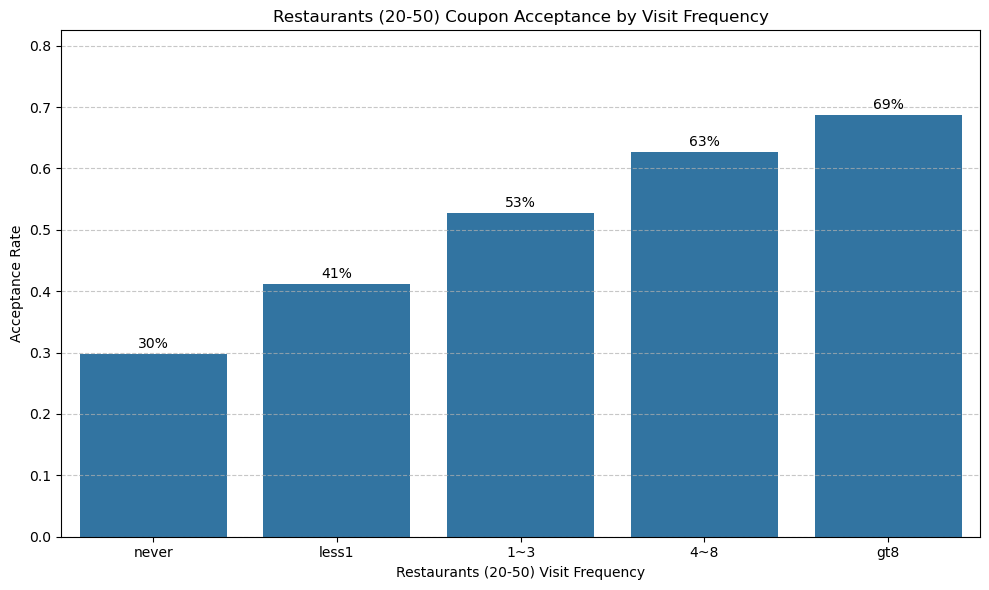

In [269]:
res_20_50_freq = res_20_50_freq.reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=res_20_50_freq,
    x='Restaurant20To50',
    y='Y'
)

for i, row in res_20_50_freq.iterrows():
    ax.text(
        i,
        row['Y'] + 0.01,
        f"{row['Y']:.0%}",
        ha='center'
    )

plt.title('Restaurants (20-50) Coupon Acceptance by Visit Frequency')
plt.xlabel('Restaurants (20-50) Visit Frequency')
plt.ylabel('Acceptance Rate')

plt.ylim(0, res_20_50_freq['Y'].max() * 1.2)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

In [183]:
res_20_50_freq = rest_20_50_data.groupby('Restaurant20To50', observed=True)['Y'].mean()
print(res_20_50_freq)

Restaurant20To50
never    0.297619
less1    0.411444
1~3      0.527415
4~8      0.626374
gt8      0.687500
Name: Y, dtype: float64


Coupon acceptance for 20–50 restaurants increases steadily with visit frequency, rising from about 30% for those who never go to nearly 69% for frequent visitors. This suggests that familiarity and existing dining habits strongly influence the likelihood of accepting these coupons.

In [206]:
rest_20_50_count_data = rest_20_50_data.pivot_table(
    values='Y',
    index='Restaurant20To50',
    columns='income',
    aggfunc='count',
    observed=True
)

rest_20_50_heatmap_data = rest_20_50_data.pivot_table(
    values='Y',
    index='Restaurant20To50',
    columns='income',
    aggfunc='mean',
    observed=True
)


rest_20_50_annotation = rest_20_50_heatmap_data.copy().astype(object)

for r in rest_20_50_heatmap_data.index:
    for c in rest_20_50_heatmap_data.columns:
        rate = rest_20_50_heatmap_data.loc[r, c]
        count = rest_20_50_count_data.loc[r, c]

        if pd.notna(rate):
            rest_20_50_annotation.loc[r, c] = f"{rate:.0%}\n(n={int(count)})"
        else:
            rest_20_50_annotation.loc[r, c] = ""

rest_20_50_heatmap_data.columns = [col.replace('$', '') for col in rest_20_50_heatmap_data.columns]

fig = px.imshow(
    rest_20_50_heatmap_data,
    text_auto=False,
    aspect='auto',
    title='Restaurant (20-50) Coupon Acceptance: Frequency vs Income',
    labels=dict(
        x="Income",
        y="Restaurant Visit Frequency",
        color="Acceptance Rate"
    )
)
fig.update_traces(text=rest_20_50_annotation.values, texttemplate="%{text}")
fig.show()

Coupon acceptance increases consistently with restaurant visit frequency across all income levels, indicating that dining habits are the strongest driver of engagement. While acceptance rises significantly with visit frequency, income has a relatively minor impact, suggesting that behavior and habits matter more than financial factors in driving coupon acceptance. Although certain income-frequency segments show high acceptance rates, smaller sample sizes in those groups suggest caution in over-interpreting those results.

### Restaurant Coupon Acceptance Analysis

Restaurant coupon acceptance is strongly influenced by prior dining behavior, with acceptance rates increasing steadily as visit frequency rises. Social context and timing further amplify this effect, as individuals are more likely to accept coupons when traveling with others and during typical meal times. While income introduces some variation, it plays a secondary role compared to established habits and situational factors. Overall, the most responsive segment consists of frequent diners in social settings, though some high-performing segments are based on smaller sample sizes and should be interpreted with caution.

#### Next Steps

Validate high-performing segments. Take a closer look at segments with very high acceptance rates but smaller sample sizes to confirm whether those patterns are reliable. Compare across restaurant price tiers. Analyze differences between <$20 and $20–$50 coupons to understand how pricing influences acceptance across segments.

#### Recommendations

Prioritize frequent diners in social settings. Target users who already dine out regularly, especially when they are with friends or partners, as they show the highest likelihood of acceptance. Time promotions around meal periods. Focus coupon delivery during lunch and dinner windows when users are more receptive to restaurant offers.

# Carry out & Take away Coupon Acceptance

For the Carry Out & Takeaway coupon analysis, the distance-related columns are used to evaluate how proximity to the restaurant influences coupon acceptance. The distance-related columns (toCoupon_GEQ5min, toCoupon_GEQ15min, and toCoupon_GEQ25min) indicate whether the destination associated with a coupon is at least a certain number of minutes away from the driver’s current route. Each column is binary, where a value of 1 means the travel time is greater than or equal to the specified threshold, and 0 means it is less than that threshold.

  distance_cat         Y
0     5–15 min  0.752577
1    15–25 min  0.724303
2      25+ min  0.732075


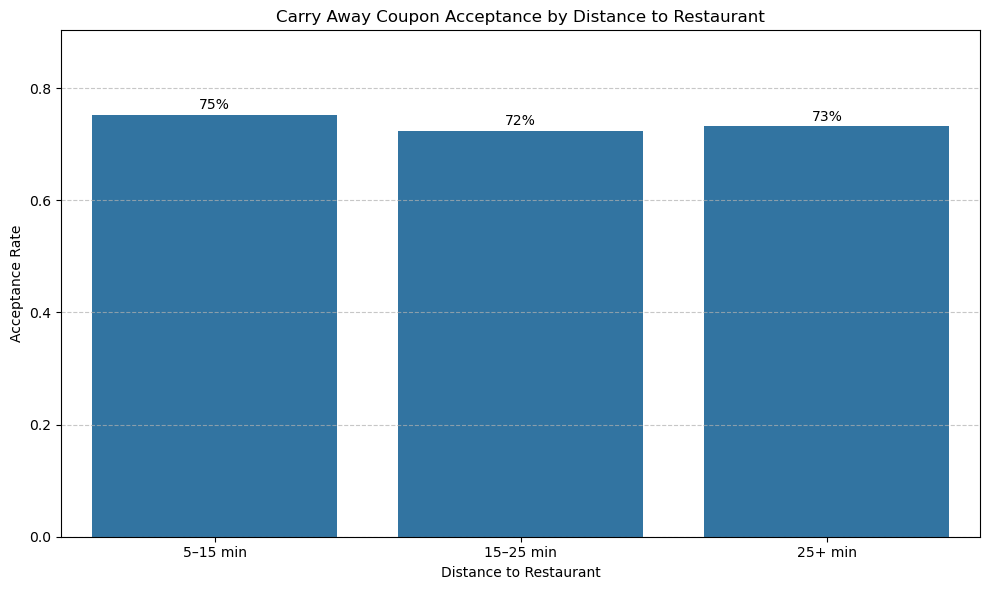

In [291]:
carry_data = data[data['coupon'] == 'Carry out & Take away'].copy()

def distance_category(row):
    if row['toCoupon_GEQ25min'] == 1:
        return '25+ min'
    elif row['toCoupon_GEQ15min'] == 1:
        return '15–25 min'
    elif row['toCoupon_GEQ5min'] == 1:
        return '5–15 min'
    else:
        return 'Under 5 min'

carry_data['distance_cat'] = carry_data.apply(distance_category, axis=1)

distance_cat_order = ['Under 5 min', '5–15 min', '15–25 min', '25+ min']

carry_data['distance_cat'] = pd.Categorical(
    carry_data['distance_cat'],
    categories=distance_cat_order,
    ordered=True
)

carry_distance = (
    carry_data
    .groupby('distance_cat', observed=True)['Y']
    .mean()
    .reset_index()
    .sort_values('distance_cat')
)

print(carry_distance)

# Since there is no data for 'Under 5 min', that column is dropped.
distance_cat_order = ['5–15 min', '15–25 min', '25+ min']

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=carry_distance,
    x='distance_cat',
    y='Y',
    order=distance_cat_order
)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.0%}",
        ha='center'
    )

plt.title('Carry Away Coupon Acceptance by Distance to Restaurant')
plt.xlabel('Distance to Restaurant')
plt.ylabel('Acceptance Rate')
plt.ylim(0, carry_distance['Y'].max() * 1.2)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

Take-away coupon acceptance remains consistently high across all distance ranges, suggesting that proximity has little impact on user behavior for this category. Unlike other coupon types where convenience plays a larger role, users appear willing to travel farther for take-away options. Overall, distance does not appear to be a strong driver of acceptance for take-away coupons.

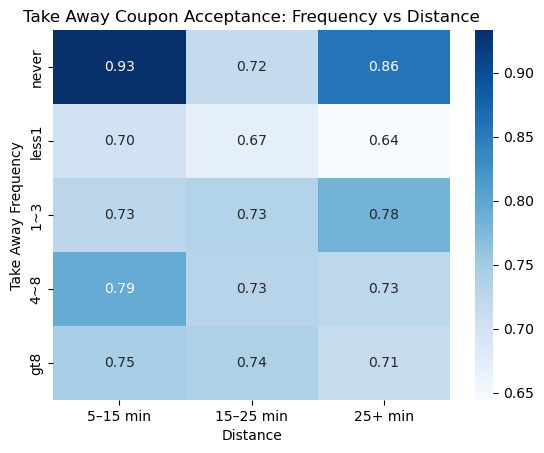

In [298]:
carry_combo = (
    carry_data
    .groupby(['distance_cat', 'CarryAway'], observed=True)['Y']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'acceptance_rate', 'count': 'n'})
)
carry_pivot = carry_combo.pivot(
    index='CarryAway',
    columns='distance_cat',
    values='acceptance_rate'
)

ax = sns.heatmap(carry_pivot, annot=True, fmt=".2f", cmap="Blues")
plt.title('Take Away Coupon Acceptance: Frequency vs Distance')
plt.xlabel('Distance')
plt.ylabel('Take Away Frequency')
plt.show()

In [303]:
carry_pivot_mean = (
    carry_data
    .groupby(['CarryAway', 'distance_cat'], observed=True)['Y']
    .mean()
    .reset_index()
    .pivot(index='CarryAway', columns='distance_cat', values='Y')
)

carry_pivot_count = (
    carry_data
    .groupby(['CarryAway', 'distance_cat'], observed=True)['Y']
    .count()
    .reset_index()
    .pivot(index='CarryAway', columns='distance_cat', values='Y')
)

carry_text = np.empty(carry_pivot_mean.shape, dtype=object)

for i in range(carry_pivot_mean.shape[0]):
    for j in range(carry_pivot_mean.shape[1]):
        rate = carry_pivot_mean.iloc[i, j]
        count = carry_pivot_count.iloc[i, j]

        if not np.isnan(rate):
            carry_text[i, j] = f"{rate:.0%}<br>n={int(count)}"
        else:
            carry_text[i, j] = ""

fig = px.imshow(
    carry_pivot_mean,
    aspect="auto",
    title='Take Away Coupon Acceptance: Frequency vs Distance',
    labels=dict(
        x='Distance to Restaurant',
        y='Take Away Visit Frequency',
        color='Acceptance Rate'
    )
)

fig.update_traces(
    text=carry_text,
    texttemplate="%{text}"
)

fig.show()

Interestingly, individuals who report never purchasing take-away food show the highest coupon acceptance rates, even with a substantial sample size. This suggests that take-away coupons are particularly effective at activating new or infrequent users, rather than influencing habitual behavior. In contrast, frequent users exhibit slightly lower acceptance rates, likely because they already engage in take-away purchases and are less dependent on promotional incentives. Overall, this indicates that take-away coupons may be most impactful as a tool for customer acquisition as well as retention.

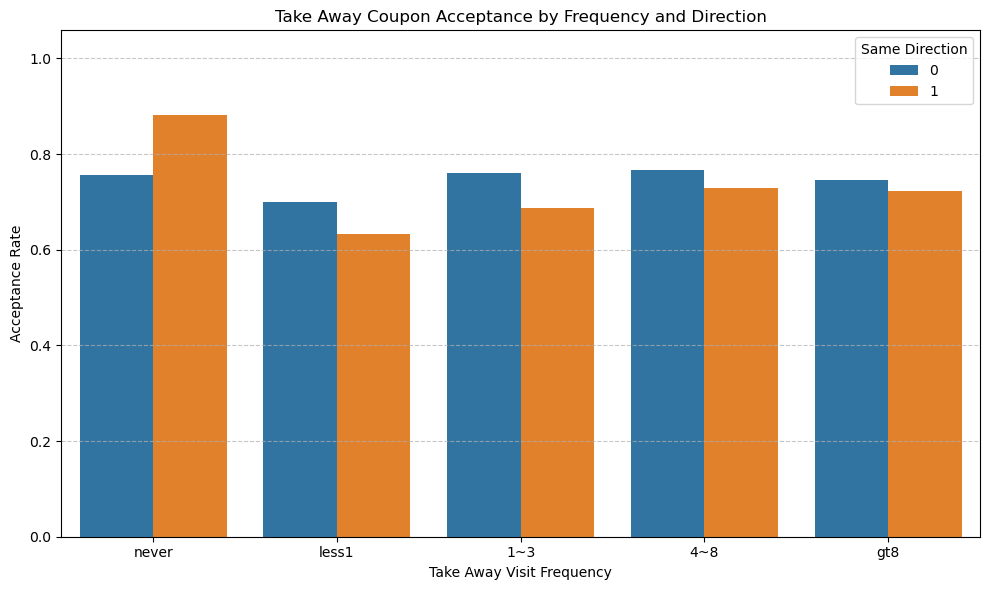

In [304]:
combo = (
    carry_data
    .groupby(['CarryAway', 'direction_same'], observed=True)['Y']
    .mean()
    .reset_index()
)

order = ['never', 'less1', '1~3', '4~8', 'gt8']

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=combo,
    x='CarryAway',
    y='Y',
    hue='direction_same',
    order=order
)

plt.title('Take Away Coupon Acceptance by Frequency and Direction')
plt.xlabel('Take Away Visit Frequency')
plt.ylabel('Acceptance Rate')

plt.ylim(0, combo['Y'].max() * 1.2)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.legend(title='Same Direction')
plt.tight_layout()
plt.show()

Direction appears to influence coupon acceptance primarily among individuals who never purchase take-away, with higher acceptance when the destination is along their current route. However, for those who visit take-away restaurants more frequently, acceptance is actually lower when the destination is in the same direction, suggesting that convenience plays a smaller role for habitual users. This pattern indicates that while non-users are more sensitive to ease and accessibility, frequent users may be driven more by their established habits.

### Carry out & Take away Coupon Acceptance Analysis

Carry-out coupon acceptance remains consistently high across most segments, indicating strong overall appeal for this category. Unlike other coupon types, traditional convenience factors such as distance and direction have relatively little impact, suggesting that users are generally willing to travel or make small detours for take-away options. Instead, frequency seems to matter more, with less frequent users actually more likely to accept the coupon. Overall, carry-out coupons appear to be broadly effective and particularly useful for encouraging new or occasional customers as well as retaining repeat customers.

#### Next Steps

Validate key findings with additional data. Look at larger samples or additional time periods to confirm patterns, especially higher acceptance among infrequent users.

#### Recommendations

Target infrequent users more aggressively. Since less frequent users show higher responsiveness, tailor campaigns to attract and convert these users into repeat customers.

## Key Findings

Analysis shows that both behavior and demographics affect coupon acceptance:

-   Visit frequency is one of the strongest predictors of acceptance. Across all coupon types, users who already engage in the behavior (e.g., dining out, going to bars, visiting coffee shops) are significantly more likely to accept coupons.
-   Convenience matters less than expected for carry-out. Distance and direction did not have as large an impact on take-away coupon acceptance, suggesting users are more flexible for this category.
-   Coupons can attract new customers in certain categories. For carry-out (and sometimes coffee), less frequent users can show high responsiveness, indicating coupons can help drive new or occasional behavior.
-   Some high-performing segments are not reliable. A few segments show very high acceptance rates but are based on small sample sizes, so those results should be interpreted with caution.

## Future Work

Possible next steps include:

-   Validate findings with additional data. Confirm that key patterns, such as the impact of visit frequency, hold across larger samples of the data.
-   Building a predictive model for coupon acceptance. Use the data to predict the likelihood of coupon acceptance, which could support more personalized and efficient targeting.